
Fitted Parameters
-----------------
Ambient Temperature (T∞): 25.00
Initial Temperature (T0): 227.91
Cooling Constant (k):     0.319681
R²:                       0.99903


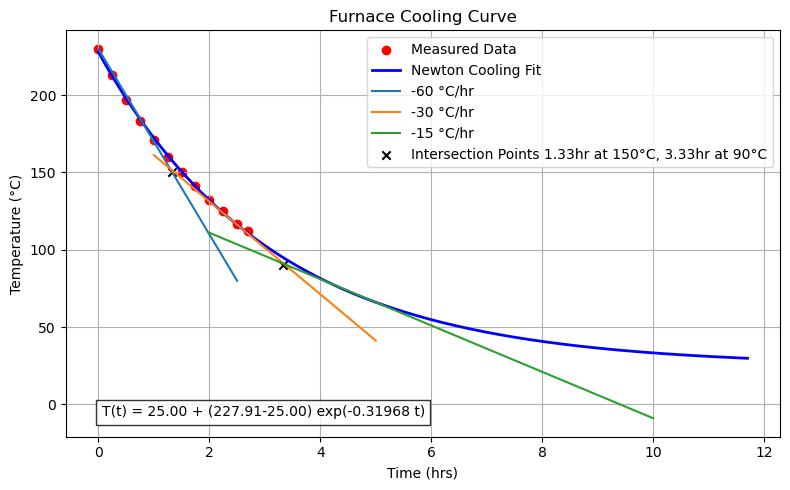

Rate of cooling at T=230°C, t=0.0: -65.53 °C/hr = -1.09 °C/min
Rate of cooling at T=213°C, t=0.25: -60.10 °C/hr = -1.00 °C/min
Rate of cooling at T=197°C, t=0.5: -54.99 °C/hr = -0.92 °C/min
Rate of cooling at T=183°C, t=0.75: -50.51 °C/hr = -0.84 °C/min
Rate of cooling at T=171°C, t=1.0: -46.67 °C/hr = -0.78 °C/min
Rate of cooling at T=160°C, t=1.25: -43.16 °C/hr = -0.72 °C/min
Rate of cooling at T=150°C, t=1.5: -39.96 °C/hr = -0.67 °C/min
Rate of cooling at T=141°C, t=1.75: -37.08 °C/hr = -0.62 °C/min
Rate of cooling at T=132°C, t=2.0: -34.21 °C/hr = -0.57 °C/min
Rate of cooling at T=125°C, t=2.25: -31.97 °C/hr = -0.53 °C/min
Rate of cooling at T=117°C, t=2.5: -29.41 °C/hr = -0.49 °C/min
Rate of cooling at T=112°C, t=2.7: -27.81 °C/hr = -0.46 °C/min


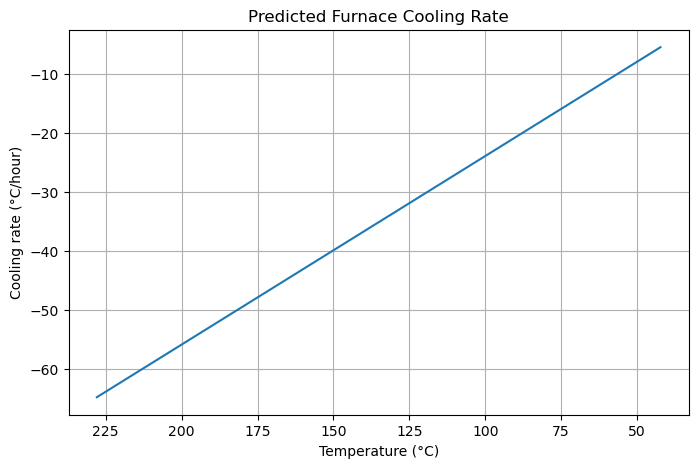

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Newton's Law of Cooling Model
# -----------------------------
T_inf = 25  # °C
def cooling_model(t, T0, k):
    return T_inf + (T0 - T_inf) * np.exp(-k * t)


# -----------------------------
# Data
# -----------------------------

#Units set the time constant k units.
times = [0,0.25,0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.7]
temps = [230,213,197,183,171,160,150,141,132,125,117,112]

times = np.array(times)
temps = np.array(temps)


# -----------------------------
# Initial parameter guesses
# -----------------------------

T0_guess = temps[0]
k_guess = 0.01

p0 = [T0_guess, k_guess]

# -----------------------------
# Fit model
# -----------------------------
params, covariance = curve_fit(
    cooling_model,
    times,
    temps,
    p0=p0,
    maxfev=10000
)

T0, k = params

# -----------------------------
# Calculate fitted values
# -----------------------------
# Extend fit beyond measured data
extra_time = 9.0   # hours (change this to how far you want to extend)

t_fit = np.linspace(
    min(times),
    max(times) + extra_time,
    500
)

T_fit = cooling_model(t_fit, *params)


predicted = cooling_model(times, *params)

# R²
ss_res = np.sum((temps - predicted) ** 2)
ss_tot = np.sum((temps - np.mean(temps)) ** 2)
r2 = 1 - ss_res / ss_tot

# -----------------------------
# Display results
# -----------------------------
print("\nFitted Parameters")
print("-----------------")
print(f"Ambient Temperature (T∞): {T_inf:.2f}")
print(f"Initial Temperature (T0): {T0:.2f}")
print(f"Cooling Constant (k):     {k:.6f}")
print(f"R²:                       {r2:.5f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(times, temps, color='red', label='Measured Data')
plt.plot(t_fit, T_fit, 'b-', linewidth=2, label='Newton Cooling Fit')

#plotting some rates of cooling for comparison
# Segment 1
t1 = np.linspace(0, 2.5, 100)
T1 = 230 - 60*t1

# Segment 2
t2start=2.5
t2 = np.linspace(1, 5.0, 100)
T2start=cooling_model(t2start, *params)
T2 = T2start - 30*(t2 - 2.5)

# Segment 3
t3start=5
t3 = np.linspace(2, 10, 100)
T3start=cooling_model(t3start, *params)
T3 = T3start - 15*(t3 - 5.0)

'''
# Segment 4
t4start=10
t4 = np.linspace(5, 15, 100)
T4start=cooling_model(t4start, *params)
T4 = T4start - 5*(t4 - 10.0)

plt.plot(t4, T4, label='-5 °C/hr')
'''



plt.plot(t1, T1, label='-60 °C/hr')
plt.plot(t2, T2, label='-30 °C/hr')
plt.plot(t3, T3, label='-15 °C/hr')

#finding the intersection points of the cooling model with the linear segments
plt.scatter([1.333, 3.333],[150,90], marker='x', color='black', label='Intersection Points 1.33hr at 150°C, 3.33hr at 90°C')


plt.xlabel("Time (hrs)")
plt.ylabel("Temperature (°C)")
plt.title("Furnace Cooling Curve")
plt.grid(True)
plt.legend()

eq = (
    f"T(t) = {T_inf:.2f} + ({T0:.2f}-{T_inf:.2f})"
    f" exp(-{k:.5f} t)"
)

plt.text(
    0.05,
    0.05,
    eq,
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', alpha=0.8)
)



plt.tight_layout()
plt.show()

#Rate of cooling:
for i in range(len(times)):
    rate = -k * (temps[i] - T_inf)
    print(f"Rate of cooling at T={temps[i]}°C, t={times[i]}: {rate:.2f} °C/hr = {rate/60:.2f} °C/min")


# -----------------------------------
# Extrapolate temperature range
# -----------------------------------

extra_time = 5   # hours beyond measured data

t_extended = np.linspace(
    min(times),
    max(times) + extra_time,
    500
)

T_extended = cooling_model(t_extended, *params)


# -----------------------------------
# Calculate cooling rate (°C/hour)
# -----------------------------------

k_hour = k 

cooling_rate = -k_hour * (T_extended - T_inf)


# -----------------------------------
# Plot cooling rate vs temperature
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    T_extended,
    cooling_rate
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Cooling rate (°C/hour)")
plt.title("Predicted Furnace Cooling Rate")
plt.grid(True)

# Reverse x-axis so hot is on the left
plt.gca().invert_xaxis()

plt.show()